<a href="https://colab.research.google.com/github/dipsom247-svg/Airline-Cargo-Operations-Performance-Analysis/blob/main/DL_LSTM_Demand_Forecasting_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airline Cargo Demand Forecasting using LSTM

Objective:
Forecast future cargo demand (Booked_KG) using Deep Learning and historical cargo booking data.

In [3]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

In [4]:
#Load Dataset
df = pd.read_csv(
    "cargo_operations_5000.csv"
)

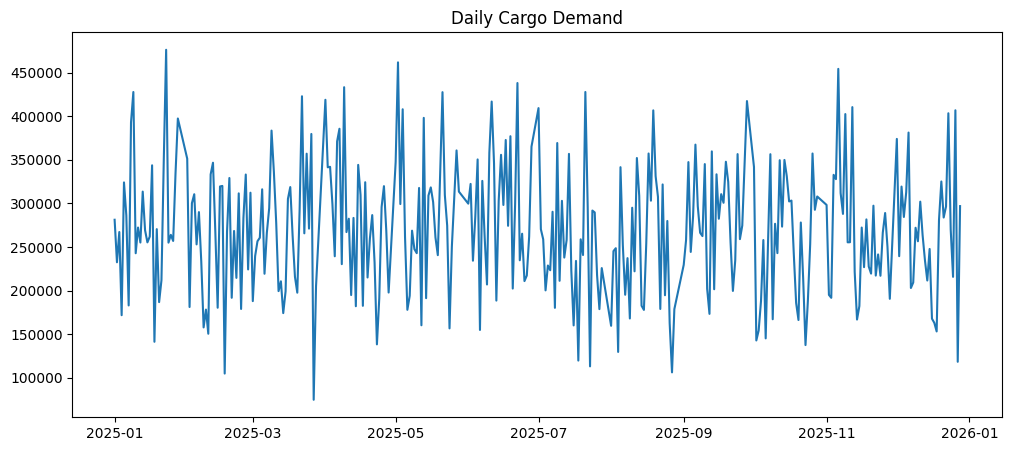

In [5]:
#Date Processing
df['Date'] = pd.to_datetime(
    df['Date']
)
df = df.sort_values(
    by='Date'
)
#Create Daily Demand Dataset
daily_demand = df.groupby(
    'Date'
)['Booked_KG'].sum().reset_index()

daily_demand.head()

#Visualization
plt.figure(figsize=(12,5))

plt.plot(
    daily_demand['Date'],
    daily_demand['Booked_KG']
)

plt.title(
    "Daily Cargo Demand"
)

plt.show()

In [8]:
#Scaling
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    daily_demand[['Booked_KG']]
)

#Sequence Creation(create 30 days sequence)
X = []
y = []

sequence_length = 30

for i in range(
    sequence_length,
    len(scaled_data)
):

    X.append(
        scaled_data[
            i-sequence_length:i
        ]
    )

    y.append(
        scaled_data[i]
    )

X = np.array(X)

y = np.array(y)

print(X.shape)

print(y.shape)

(306, 30, 1)
(306, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.1232 - val_loss: 0.0522
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0521 - val_loss: 0.0372
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0427 - val_loss: 0.0345
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0389 - val_loss: 0.0343
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0379 - val_loss: 0.0343
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0380 - val_loss: 0.0338
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0383 - val_loss: 0.0337
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0404 - val_loss: 0.0368
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0385 - val_loss: 0.0350
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0357 - val_loss: 0.0337
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0380 - val_loss: 0.0345
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0386 - val_loss: 0.0341


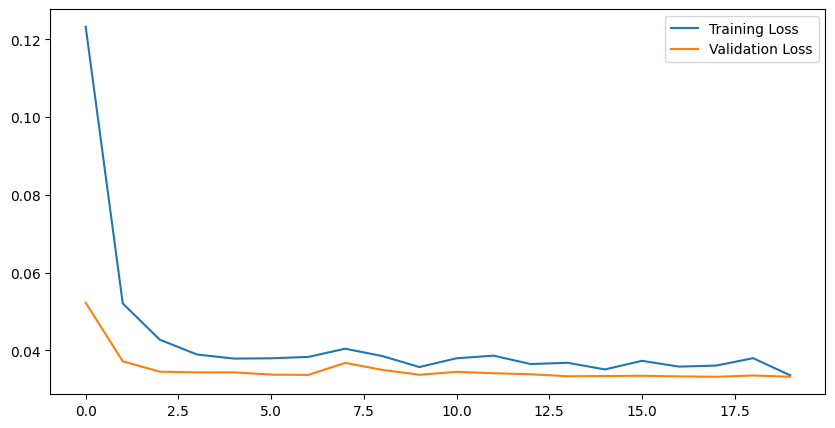

In [11]:
#Train Test Split
split = int(
    len(X)*0.8
)

X_train = X[:split]

X_test = X[split:]

y_train = y[:split]

y_test = y[split:]

#Build LSTM Model
model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            1
        )
    )
)
#Dropout
model.add(
    Dropout(0.2)
)
#Second LSTM Layer
model.add(
    LSTM(
        50
    )
)
#Dropout
model.add(
    Dropout(0.2)
)

#Output Layer
model.add(
    Dense(1)
)

#Compile
model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

#Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(
        X_test,
        y_test
    )
)

#Training Curve

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history[
        'val_loss'
    ],
    label='Validation Loss'
)

plt.legend()

plt.show()


In [13]:
#Prediction

predictions = model.predict(
    X_test
)

##Inverse Transform
predictions = scaler.inverse_transform(
    predictions
)

actual = scaler.inverse_transform(
    y_test
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


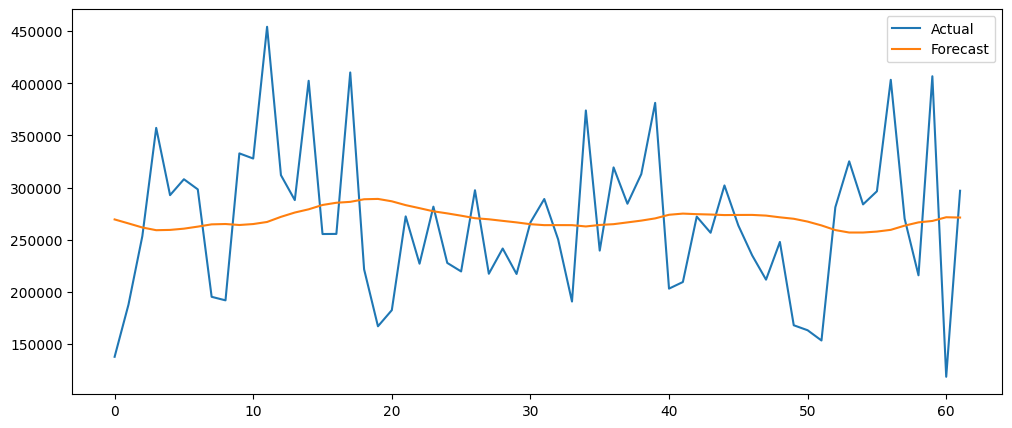

In [14]:
#Actual vs Forecast
plt.figure(figsize=(12,5))

plt.plot(
    actual,
    label='Actual'
)

plt.plot(
    predictions,
    label='Forecast'
)

plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━

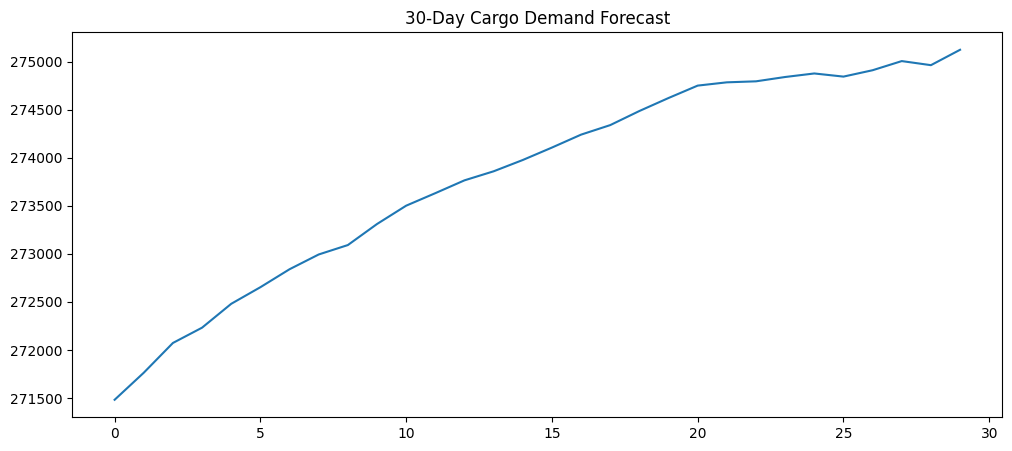

In [17]:
import numpy as np
#Forecast Next 30 Days
##  Last sequence
last_sequence = scaled_data[
    -30:
]

#Reshape
current_batch = last_sequence.reshape(
    (1,30,1)
)

#Generate Forecast
future_predictions = []

for i in range(30):

    current_pred = model.predict(
        current_batch
    )[0]

    future_predictions.append(
        current_pred
    )

    current_batch = np.append(
        current_batch[:,1:,:],
        [[current_pred]],
        axis=1
    )

#Convert back
future_predictions = scaler.inverse_transform(
    future_predictions
)

#Plot 30-Day Forecast
plt.figure(figsize=(12,5))

plt.plot(
    future_predictions
)

plt.title(
    "30-Day Cargo Demand Forecast"
)

plt.show()

In [18]:
#Model Evaluation
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print("RMSE :", rmse)

RMSE : 73144.34168279126


**Business Recommendations**
1. Use demand forecasts for route-level cargo planning.

2. Increase capacity during forecasted peak demand periods.

3. Integrate forecasting models with cargo booking systems.

4. Continuously retrain models using new operational data.

This Deep Learning model demonstrates how historical cargo booking data can be leveraged to forecast future demand.

Combining EDA, Machine Learning, and Deep Learning provides a complete analytics framework for airline cargo demand forecasting and operational optimization.